# Real-data single-trace fit (Guarino)

Proof-of-concept fit for thesis §5.4 "Outlook: Training on Voltage Recordings".
Loads one real IDthresh recording and runs single-stage gradient-based fitting under the
Guarino feature-based loss.

Same trainable parameter set as the recovery-radius benchmark of §5.3.2 (six membrane
parameters; adaptation held at initial values) and the same surrogate kernel
(SuperSpike, $\beta=6$). The Guarino loss includes the $V_{\mathrm{stimend}}$ feature
which provides the surrogate-bypass voltage signal documented in §5.2.4 — no extra
subthreshold term required. Easy to swap the trace ID below to try other amplitudes from
the same cell.

## 1. Configuration

In [1]:
import logging

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import config

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoLossConfig,
    extract_experimental_features,
    make_guarino_loss_fn,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    trace_stim_window_plot,
    training_history_plot,
)
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

DATA_DIR = (
    "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/"
    "mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"
)
TRACE_ID = "553"            # 540 / 545 / 550 / 553 (subthreshold -> high-rate)
# Trace 553 has 8 visible spikes but peaks reach only ~+2 mV; threshold=0 would
# miss most of them. -10 mV captures all 8.
SPIKE_THRESHOLD_MV = -10.0

## 2. Load real IDthresh trace

Trace 553: 4000 samples, dt=0.100 ms
  Stim window: [1000:4000] (300 ms)
  Stim current: 421.3 pA
  Detected spikes: 8


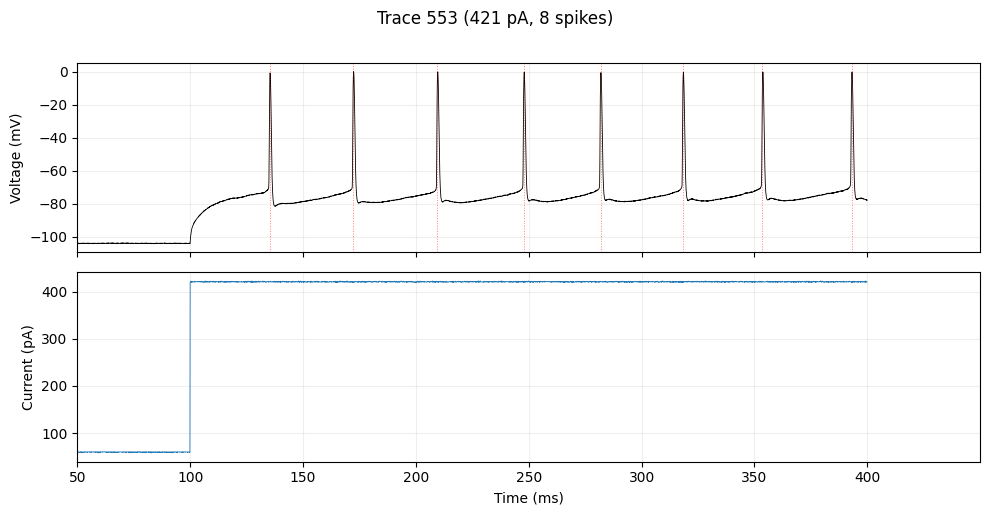

In [2]:
raw = load_trace(
    voltage_path=f"{DATA_DIR}ECBL_IDthresh_ch5_{TRACE_ID}.dat",
    current_path=f"{DATA_DIR}ECBL_IDthresh_ch4_{TRACE_ID}.dat",
    spike_threshold_mv=SPIKE_THRESHOLD_MV,
)

data = crop_to_stim_window(
    raw, max_duration_ms=300.0, padding_ms_before=100.0,
)

print(f"Trace {TRACE_ID}: {data.n_samples} samples, dt={data.dt_ms:.3f} ms")
print(f"  Stim window: [{data.stim_start_idx}:{data.stim_end_idx}] ({data.stim_duration_ms:.0f} ms)")
print(f"  Stim current: {data.stim_current_pA:.1f} pA")
print(f"  Detected spikes: {data.n_spikes}")

trace_stim_window_plot(data)
plt.gcf().suptitle(f"Trace {TRACE_ID} ({data.stim_current_pA:.0f} pA, {data.n_spikes} spikes)", y=1.02)
plt.show()

## 3. Initial parameters

Tuned by manual coarse search at $I = 421$ pA against the 8-spike target.
Constraints used:
- $E_L$ matches the pre-stim resting potential ($-104$ mV).
- $g_L$ small enough that $V_\infty = E_L + I/g_L \gtrsim V_T - $ few$\cdot\Delta_T$, so the exp term can fire.
- $C_m$ around $200$ pF gives $\tau_m = C_m / g_L \approx 20$ ms, matching the target ISI of $\sim$37 ms.

Six membrane parameters trainable; adaptation $(a, b, \tau_w)$ held at initial values
(matching the recovery-radius benchmark scope of §5.3.2 — adding them as trainable in
single-trace fits did not improve $\Gamma$ in any HP variant tried).

In [3]:
initial_params = dict(NAUD_PARAMETERS["tonic"])
initial_params["v_threshold"] = 0.0
initial_params["E_L"]         = -103.0
initial_params["g_L"]         = 13.0
initial_params["C_m"]         = 100.0
initial_params["v_T"]         = -71.0
initial_params["delta_T"]     = 0.2
initial_params["v_reset"]     = -85.0
initial_params["tau_w"]       = 10.0
initial_params["a"]           = 0.0
initial_params["b"]           = 30.0

TRAINABLE = ["C_m", "g_L", "E_L", "v_T", "delta_T", "v_reset"]

print(f"{'Parameter':<12} {'Initial':>10} {'Bounds':>22}")
print("-" * 48)
for k in TRAINABLE:
    v = initial_params[k]
    b = PARAM_BOUNDS[k]
    pos = (v - b.min) / (b.max - b.min) * 100
    print(f"  {k:<10} {v:>10.3f}   [{b.min:>6.1f}, {b.max:>6.1f}]  ({pos:>3.0f}%)")

Parameter       Initial                 Bounds
------------------------------------------------
  C_m           100.000   [  10.0,  240.0]  ( 39%)
  g_L            13.000   [   6.0,   14.0]  ( 88%)
  E_L          -103.000   [-110.0,  -65.0]  ( 16%)
  v_T           -71.000   [ -90.0,  -55.0]  ( 54%)
  delta_T         0.200   [   1.0,   20.0]  ( -4%)
  v_reset       -85.000   [ -95.0,  -65.0]  ( 33%)


INFO:2026-05-17 17:34:56,095:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial sim: 7 spikes (target: 8)


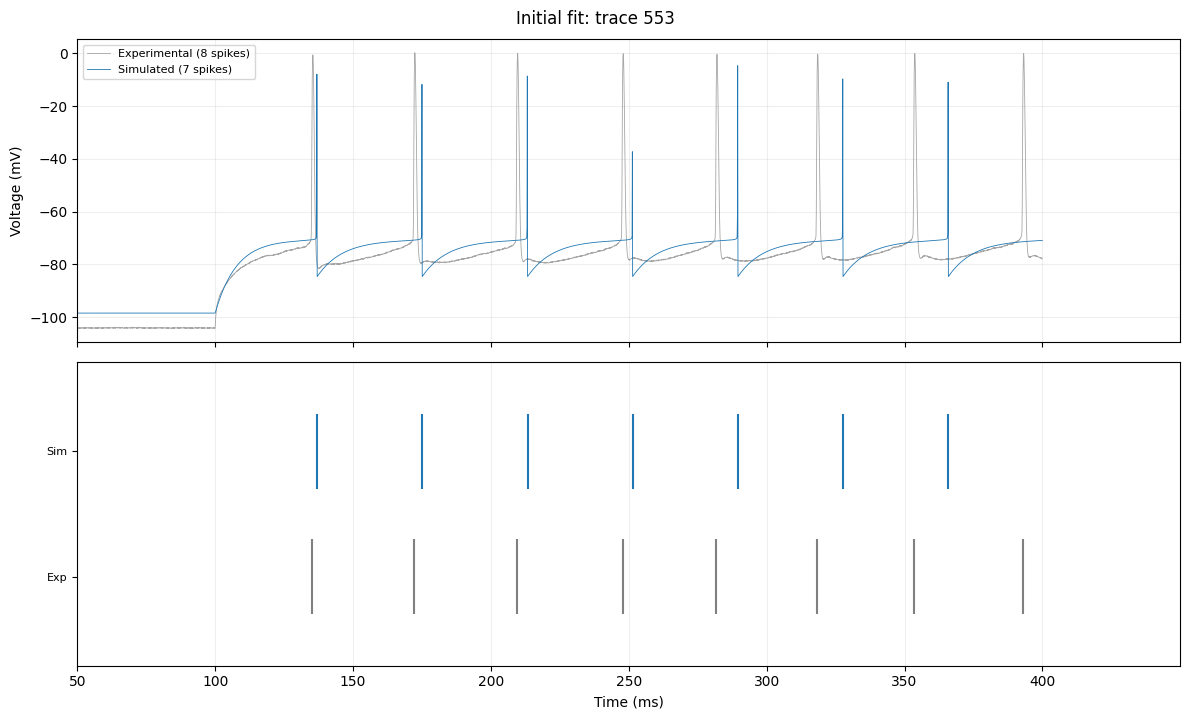

In [4]:
sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial sim: {sim_init.n_spikes} spikes (target: {data.n_spikes})")

fit_comparison_plot(data, sim_init)
plt.gcf().suptitle(f"Initial fit: trace {TRACE_ID}", y=1.02)
plt.show()

## 4. Build trainable cell

Surrogate: SuperSpike, $\beta=25$ — sharp surrogate that the surrogate-sweep figure of
§5.2.4 flags as the dead-neuron regime; usable here because the Guarino loss includes
the surrogate-bypass $V_{\mathrm{stimend}}$ feature (§5.2.4 bypass subsection).
Optimiser: Adam at learning rate $0.001$. With `return_best=True` the trainer keeps
the lowest-loss checkpoint; on this fit the best epoch sits around epoch 25–30, and
the loss is noisy thereafter due to discrete spike-count transitions interacting with
the narrow $\beta=25$ window.

In [5]:
training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.001,
    n_epochs=80,
    surrogate_type="superspike",
    surrogate_slope=25.0,
    print_every=10,
    polyak_alpha=0.8,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
    trainable_params=TRAINABLE,
)

cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=jnp.array(data.current), v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    config=training_config,
    trainable_params=TRAINABLE,
)
print(f"Trainable params handles: {[list(p.keys())[0] for p in trainable_params]}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Trainable params handles: ['capacitance', 'AdEx_g_L', 'AdEx_E_L', 'AdEx_v_T', 'AdEx_delta_T', 'AdEx_v_reset']


## 5. Construct Guarino loss

Extract the eight Guarino features (four spike times, two inverse ISIs, firing
frequency, $V_{\mathrm{stimend}}$) from the real voltage trace, then build the
loss factory against those targets. Feature weights match the per-cell tuning from
`training_multistage.ipynb`.

In [6]:
loss_config = GuarinoLossConfig(
    weight_t_first=25.0,
    weight_t_second=20.0,
    weight_t_third=15.0,
    weight_t_last=10.0,
    weight_firing_freq=10.0,
    weight_spike_count=0.2,
)

exp_voltage = jnp.array(data.voltage)
exp_features = extract_experimental_features(
    voltage_trace=exp_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    spike_threshold_mv=SPIKE_THRESHOLD_MV,
)
print(f"Experimental features: "
      f"n_spikes={float(exp_features.n_spikes):.0f}  "
      f"freq={float(exp_features.firing_frequency):.1f} Hz  "
      f"t_first={float(exp_features.t_first_spike):.1f} ms  "
      f"v_stimend={float(exp_features.v_stim_end):.1f} mV")

loss_fn = make_guarino_loss_fn(cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms, exp_features=exp_features, stim_duration_ms=data.stim_duration_ms, stim_end_index=data.stim_end_idx, loss_config=loss_config)

initial_loss = float(loss_fn(trainable_params))
print(f"Initial Guarino loss: {initial_loss:.4f}")

Experimental features: n_spikes=8  freq=26.7 Hz  t_first=135.3 ms  v_stimend=-77.9 mV
Initial Guarino loss: 3.2811


## 6. Train

In [7]:
result = train(
    loss_fn=loss_fn,
    trainable_params=trainable_params,
    config=training_config,
    initial_params=initial_params,
)

print("\nTraining complete.")
print(f"  Best loss:   {result.best_loss:.4f} (epoch {result.best_epoch})")
print(f"  Final loss:  {result.final_loss:.4f}")
print(f"  Total time:  {result.total_time:.1f} s")

Training: optimizer=adam lr=0.001 epochs=80 surrogate=superspike slope=25.0 sigmoid_transform
Epoch    0 | loss=0.722085 | grad_norm=1.66e+01 | C_m=100.0548, g_L=13.0009, E_L=-103.0059, v_T=-70.9913, delta_T=1.0019, v_reset=-85.0067
Epoch   10 | loss=1.245508 | grad_norm=9.51e-02 | C_m=100.3287, g_L=13.0057, E_L=-103.0381, v_T=-70.9438, delta_T=1.0019, v_reset=-85.0435
Epoch   20 | loss=1.302231 | grad_norm=3.94e+00 | C_m=100.3029, g_L=13.0054, E_L=-103.0362, v_T=-70.9466, delta_T=1.0019, v_reset=-85.0422
Epoch   30 | loss=1.183796 | grad_norm=1.71e+02 | C_m=100.3118, g_L=13.0056, E_L=-103.0373, v_T=-70.9449, delta_T=1.0019, v_reset=-85.0438
Epoch   40 | loss=3.660595 | grad_norm=9.49e+01 | C_m=100.4519, g_L=13.0077, E_L=-103.0521, v_T=-70.9231, delta_T=1.0019, v_reset=-85.0599
Epoch   50 | loss=0.967648 | grad_norm=2.98e+00 | C_m=100.2091, g_L=13.0041, E_L=-103.0275, v_T=-70.9592, delta_T=1.0019, v_reset=-85.0466
Epoch   60 | loss=0.563537 | grad_norm=3.13e+00 | C_m=100.0633, g_L=13.0


Training complete.
  Best loss:   0.5515 (epoch 58)
  Final loss:  1.3751
  Total time:  1.0 s


## 7. Evaluate fit

Re-simulate the trace with the trained parameters using the non-surrogate forward sim
(matches the benchmark's $\Gamma$-evaluation protocol in §5.3.2). Coincidence factor
$\Gamma$ is computed at $\Delta = 4$ ms tolerance.

In [8]:
trained_dict = result.get_params_dict()
params_final = dict(initial_params)
params_final.update(trained_dict)

sim_final = simulate_with_current_trace(
    params=params_final,
    current_trace_pA=data.current, v_init=data.voltage[0],
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

DELTA_MS = 4.0

def _gamma(sim):
    if sim.n_spikes == 0 or data.n_spikes == 0:
        return None
    return coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=DELTA_MS,
    )

cf_init = _gamma(sim_init)
cf = _gamma(sim_final)
gamma_init_str = f"{cf_init.gamma:+.3f}" if cf_init else "N/A"
gamma_str      = f"{cf.gamma:+.3f}"      if cf      else "N/A"

print(f"{'':<14} {'sim':>5} {'target':>7}  {'Gamma':>8}")
print("-" * 42)
print(f"  {'initial':<12} {sim_init.n_spikes:>5} {data.n_spikes:>7}  {gamma_init_str}")
print(f"  {'trained':<12} {sim_final.n_spikes:>5} {data.n_spikes:>7}  {gamma_str}")

print("\nParameter recovery:")
print(f"{'Parameter':<12} {'Initial':>10} {'Final':>10} {'Delta':>10}")
print("-" * 44)
for k in TRAINABLE:
    init_v = initial_params[k]
    final_v = params_final[k]
    delta = final_v - init_v
    print(f"  {k:<10} {init_v:>10.3f} {final_v:>10.3f} {delta:>+10.3f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
                 sim  target     Gamma
------------------------------------------
  initial          7       8  +0.411
  trained          8       8  +1.000

Parameter recovery:
Parameter       Initial      Final      Delta
--------------------------------------------
  C_m           100.000    100.082     +0.082
  g_L            13.000     13.002     +0.002
  E_L          -103.000   -103.014     -0.014
  v_T           -71.000    -70.979     +0.021
  delta_T         0.200      1.002     +0.802
  v_reset       -85.000    -85.035     -0.035


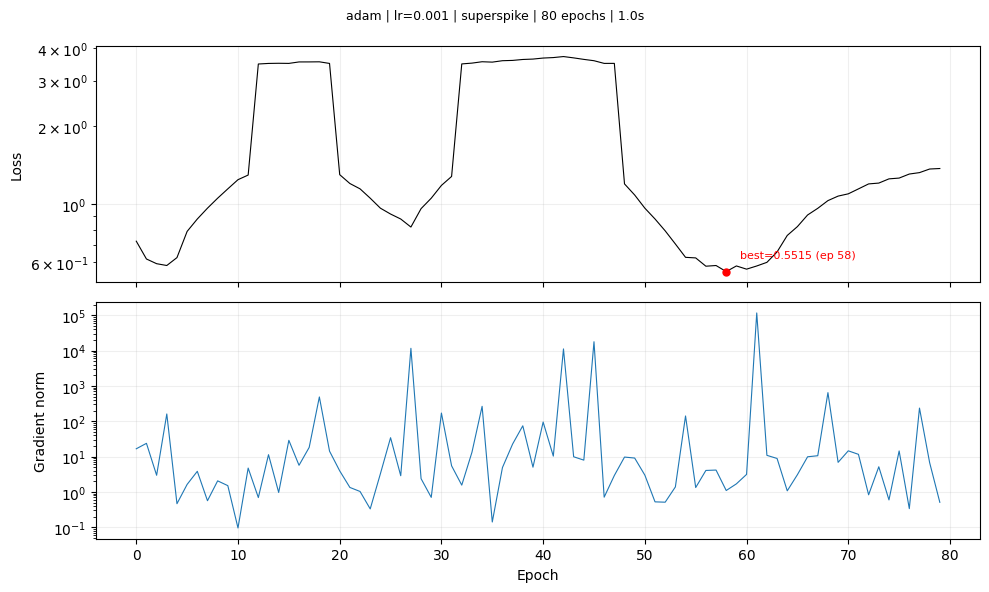

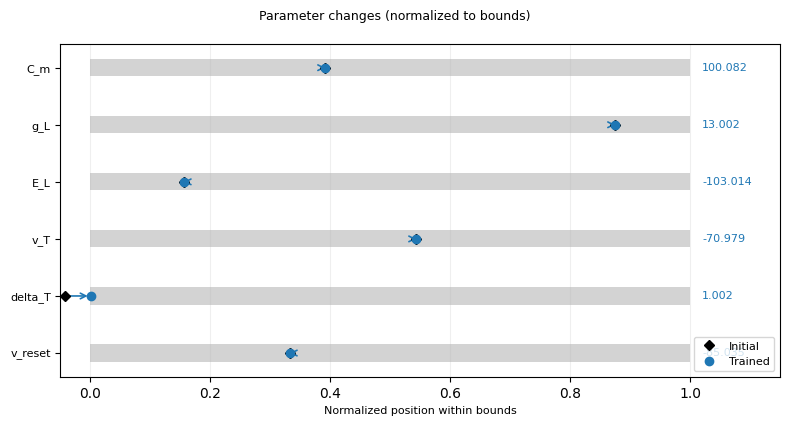

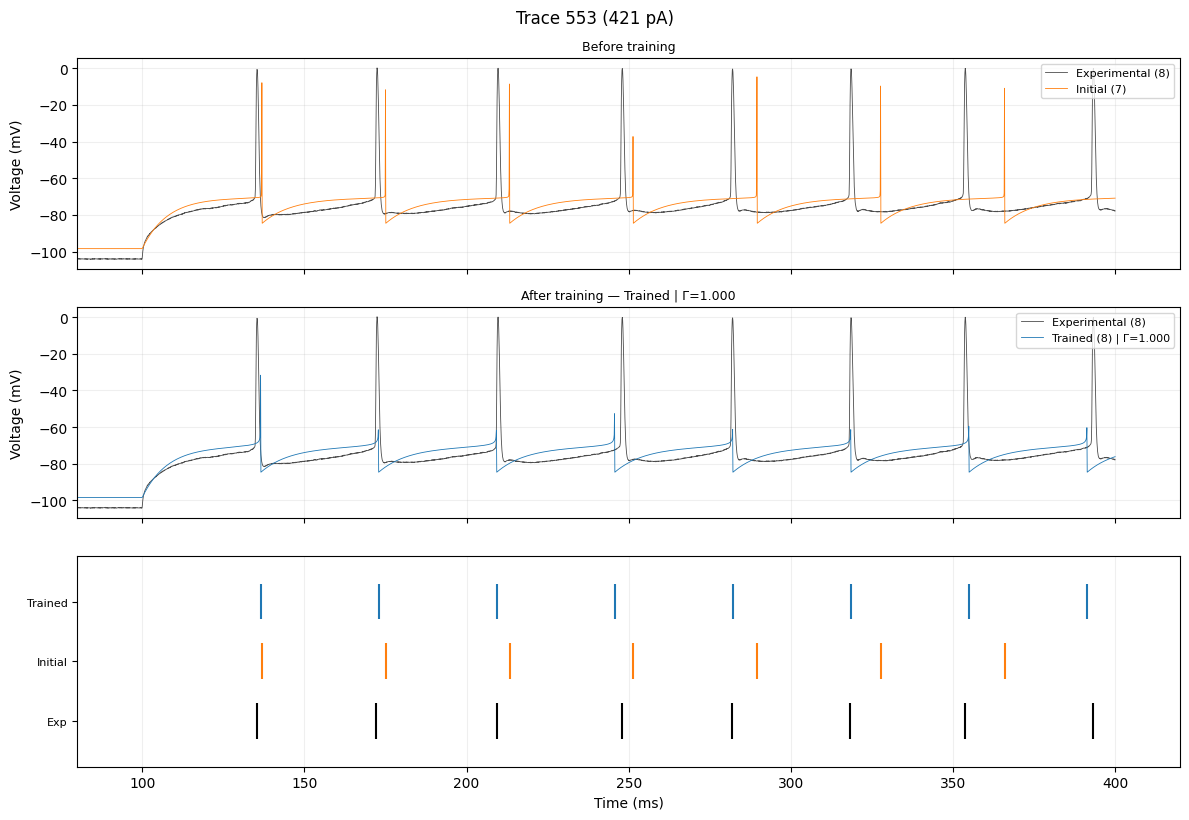

In [9]:
FIG_DIR = "/Users/paulmayer/Projects/university/40_thesis/2_thesis/figures"
FIG_STEM = f"real_singletrace_{TRACE_ID}"

training_history_plot(result)
plt.savefig(f"{FIG_DIR}/{FIG_STEM}_training_history.pdf", dpi=300, bbox_inches="tight")
plt.show()

parameter_comparison_plot(result)
plt.savefig(f"{FIG_DIR}/{FIG_STEM}_parameter_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

fit_before_after_plot(
    data, sim_init, [sim_final],
    coincidence=[cf], labels=["Trained"],
)
plt.gcf().suptitle(f"Trace {TRACE_ID} ({data.stim_current_pA:.0f} pA)", y=1.02)
plt.savefig(f"{FIG_DIR}/{FIG_STEM}_fit.pdf", dpi=300, bbox_inches="tight")
plt.show()